<center><img src="car.jpg" width=500></center>


Insurance companies invest a lot of time and money into optimizing their pricing and accurately estimating the likelihood that customers will make a claim. In many countries insurance it is a legal requirement to have car insurance in order to drive a vehicle on public roads, so the market is very large!

(`Source: https://www.accenture.com/_acnmedia/pdf-84/accenture-machine-leaning-insurance.pdf`) 

Knowing all of this, On the Road car insurance have requested your services in building a model to predict whether a customer will make a claim on their insurance during the policy period. As they have very little expertise and infrastructure for deploying and monitoring machine learning models, they've asked you to identify the single feature that results in the best performing model, as measured by accuracy, so they can start with a simple model in production.

They have supplied you with their customer data as a csv file called `car_insurance.csv`, along with a table detailing the column names and descriptions below.



## The dataset

| Column | Description |
|--------|-------------|
| `id` | Unique client identifier |
| `age` | Client's age: <br> <ul><li>`0`: 16-25</li><li>`1`: 26-39</li><li>`2`: 40-64</li><li>`3`: 65+</li></ul> |
| `gender` | Client's gender: <br> <ul><li>`0`: Female</li><li>`1`: Male</li></ul> |
| `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |
| `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |
| `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |
| `credit_score` | Client's credit score (between zero and one) |
| `vehicle_ownership` | Client's vehicle ownership status: <br><ul><li>`0`: Does not own their vehilce (paying off finance)</li><li>`1`: Owns their vehicle</li></ul> |
| `vehcile_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |
| `married` | Client's marital status: <br><ul><li>`0`: Not married</li><li>`1`: Married</li></ul> |
| `children` | Client's number of children |
| `postal_code` | Client's postal code | 
| `annual_mileage` | Number of miles driven by the client each year |
| `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |
| `speeding_violations` | Total number of speeding violations received by the client | 
| `duis` | Number of times the client has been caught driving under the influence of alcohol |
| `past_accidents` | Total number of previous accidents the client has been involved in |
| `outcome` | Whether the client made a claim on their car insurance (response variable): <br><ul><li>`0`: No claim</li><li>`1`: Made a claim</li></ul> |

### Random Forest Classification — Required Steps

1. **Import the required libraries**

   * Pandas
   * Visualization libraries
   * Scikit-learn preprocessing, pipeline, Random Forest, and evaluation tools

2. **Load the `car_insurance.csv` dataset**

   * Display the first few rows.

3. **Explore the dataset**

   * Check `shape`, `info()`, and `describe()`.
   * Check for missing values.
   * Identify numerical and categorical columns.
   * Visualize the `outcome` target distribution.

4. **Prepare features and target**

   * Create `X` containing the input features.
   * Create `y` containing `outcome`.
   * Decide whether the `id` column should be removed.

5. **Identify feature types**

   * Numerical
   * Categorical
   * Ordinal, where appropriate

6. **Preprocess the features**

   * Apply suitable encoding/transformation.
   * Organize preprocessing using `ColumnTransformer`.

7. **Split the data**

   * 80% training data.
   * 20% testing data.
   * Use `random_state`.

8. **Create a machine learning `Pipeline`**

   * Combine the `ColumnTransformer` preprocessing with `RandomForestClassifier`.

9. **Train the Random Forest**

   * Fit the pipeline using `X_train` and `y_train`.

10. **Make predictions**

    * Predict `X_test`.
    * Store the result as `y_pred`.

11. **Evaluate the model**

    * Accuracy
    * Confusion Matrix
    * Precision
    * Recall
    * F1-score
    * Classification Report

12. **Write a conclusion**

    * Explain the preprocessing performed.
    * State the model's performance.
    * Interpret the evaluation metrics.
    * Conclude how well the Random Forest predicts insurance claims.

**Overall workflow:**

`Explore → Prepare X/y → Preprocess → Split → Pipeline → Random Forest → Train → Predict → Evaluate → Conclusion`


### 1

In [59]:
# Import required modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ML libraries
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report,mean_squared_error,mean_absolute_error,r2_score,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
# Start coding!

### 2

In [3]:
df = pd.read_csv('car_insurance.csv')

### 3

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         10000 non-null  float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       10000 non-null  float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

In [40]:
df.describe()

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,duis,past_accidents,outcome
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,1.489500,0.499000,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,1.025278,0.500024,0.130752,0.459578,0.500022,0.463008,18915.613855,2680.167384,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.000000,0.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,1.000000,0.000000,0.431509,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,1.000000,0.000000,0.515813,1.000000,0.000000,1.000000,10238.000000,11697.003207,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,2.000000,1.000000,0.607607,1.000000,1.000000,1.000000,32765.000000,13000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,3.000000,1.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [39]:
df.shape

(10000, 18)

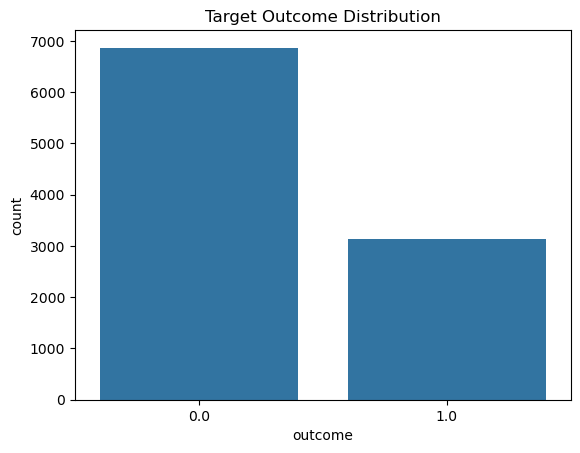

In [41]:
sns.countplot(x='outcome', data=df)
plt.title('Target Outcome Distribution')
plt.show()

### 4

In [42]:
X = df.drop(columns=['id','outcome'])
y = df['outcome']

### 5

In [46]:
num_cols = ['credit_score', 'annual_mileage', 'speeding_violations', 'duis', 'past_accidents']
cat_cols = ['age', 'gender', 'driving_experience', 'education', 'income', 
            'vehicle_ownership', 'vehicle_year', 'married', 'children', 
            'postal_code', 'vehicle_type']

### 6

In [47]:
num_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num',num_trans,num_cols),
    ('cat',cat_trans,cat_cols)
])

### 7

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=67)

### 8

In [49]:
rf_clf = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(n_estimators=100,random_state=67))
])

### 9 and 10

In [53]:
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

### 11

In [60]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
fs = f1_score(y_test, y_pred)

In [61]:
print(f"Accuracy score: {acc:.4f}")
print(f"Precision score: {prec:.4f}")
print(f"Recall score: {recall:.4f}")
print(f"F1 score: {fs:.4f}")

Accuracy score: 0.8365
Precision score: 0.7583
Recall score: 0.7167
F1 score: 0.7369


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88      1361
         1.0       0.76      0.72      0.74       639

    accuracy                           0.84      2000
   macro avg       0.81      0.80      0.81      2000
weighted avg       0.83      0.84      0.84      2000



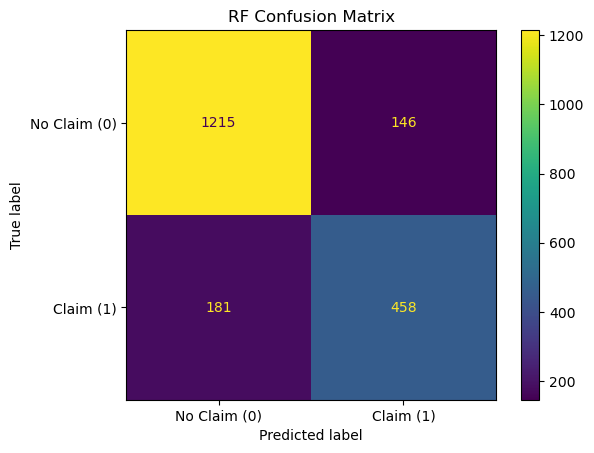

In [63]:
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Claim (0)','Claim (1)'])
display.plot()
plt.title('RF Confusion Matrix')
plt.show()

### 12

**Explain the preprocessing performed.**

The missing numerical features were imputed with mean using StandardScaler, while the categorical features were imputed with mode and encoded using OneHotEncoder. All prepocessing steps were done in a ColumnTransformer inside a pipeline to prevent data leakage.

**State the model's performance.**

The RandomForestClassifier achieved an accuracy score of 0.8365, outperforming the baseline single-feature models (driving_experience)

**Interpret the evaluation metrics.**

Class 0 achieved 0.87 precision and F1-score of 0.88. The model is highly accurate at identifying low-risk policyholders who will not file a claim.

Class 1 achieved 0.76 precision and F1-score of 0.74. When the model flags a customer as likely to make a claim, it is correct 76% of the time and successfully identifies 72% of all actual claims filled.

**Conclude how well the RF predicts claims**

The RF model demonstrates strong predictive capability for evaluating insurance risk, by combining demographic, historical and vehicle features into an ensemble model. The company can accurately forecast claim probabilities and optimize risk assessments using the model above, rather than relying on a single attribute.